In [1]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

enc = 'utf-8'

In [2]:
def plot_log2_frequency(dataset: pd.DataFrame, target_col: str):
    """
    Plots the frequency of each distinct integer value in a column on a log2-scaled x-axis.

    Parameters:
    - dataset (pd.DataFrame): The input DataFrame.
    - target_col (str): The name of the target column to analyze.
    """
    # Count occurrences
    value_counts = dataset[target_col].value_counts().sort_index()
    plot_df = value_counts.reset_index()
    plot_df.columns = ['value', 'count']

    # Replace 0 with small positive number to avoid log(0)
    plot_df['value_log'] = plot_df['value'].replace({0: 0.5})
    plot_df['value_str'] = plot_df['value'].astype(str)

    # Create bar plot
    fig = go.Figure(data=[
        go.Bar(
            x=plot_df['value_log'],
            y=plot_df['count'],
            text=plot_df['value_str'],
            marker_color='crimson'
        )
    ])

    # Configure layout
    fig.update_layout(
        title=f'Frequency of Each Target Value in "{target_col}" (log₂ x-axis)',
        xaxis_type='log',
        xaxis_title='Target Value',
        yaxis_title='Count',
        xaxis=dict(
            type='log',
            dtick=np.log10(2),
        )
    )

    # Show actual values on hover
    fig.update_traces(hovertemplate='Value: %{text}<br>Count: %{y}<extra></extra>')

    fig.show()

In [3]:
dataset = pd.read_csv(f'../../data/ExtNord/CM_ExtNord_Dataset_2015-2024.csv', encoding=enc)

In [4]:
dataset.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

In [5]:
dataset.head()

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-10,2014,10,-0.866,...,2,17,3,12,2,17,0,0,0,0
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-10,2014,10,-0.866,...,0,0,0,0,0,0,0,0,0,0
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-10,2014,10,-0.866,...,3,83,1,0,0,1,0,0,0,0
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-10,2014,10,-0.866,...,1,8,4,3,1,8,0,0,0,0
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-10,2014,10,-0.866,...,4,41,0,3,0,3,0,0,0,0


In [6]:
dataset['location'] = list(zip(dataset['GID0'], dataset['GID1'], dataset['GID2'], dataset['GID3']))
dataset.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataset['dt_prediction'] = pd.to_datetime(dataset['dt_prediction']).dt.to_period('M')

In [7]:
dataset = dataset[['location'] + dataset.columns.to_list()[:-1]]

In [8]:
dataset.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,2,17,3,12,2,17,0,0,0,0
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,0,0,0,0,0,0,0,0,0,0
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,3,83,1,0,0,1,0,0,0,0
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,1,8,4,3,1,8,0,0,0,0
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,4,41,0,3,0,3,0,0,0,0


In [9]:
plot_log2_frequency(dataset, 'Case_UND5')

In [10]:
plot_log2_frequency(dataset, 'Case_OVR5')

In [11]:
plot_log2_frequency(dataset, 'Case_PRGN')

In [12]:
plot_log2_frequency(dataset, 'Case_TOTAL')

In [13]:
plot_log2_frequency(dataset, 'Sevr_UND5')

In [14]:
plot_log2_frequency(dataset, 'Sevr_OVR5')

In [15]:
plot_log2_frequency(dataset, 'Sevr_PRGN')

In [16]:
plot_log2_frequency(dataset, 'Sevr_TOTAL')

In [17]:
plot_log2_frequency(dataset, 'Hosp_UND5')

In [18]:
plot_log2_frequency(dataset, 'Hosp_OVR5')

In [19]:
plot_log2_frequency(dataset, 'Hosp_PRGN')

In [20]:
plot_log2_frequency(dataset, 'Hosp_TOTAL')

In [21]:
plot_log2_frequency(dataset, 'Death_UND5')

In [22]:
plot_log2_frequency(dataset, 'Death_OVR5')

In [23]:
plot_log2_frequency(dataset, 'Death_PRGN')

In [24]:
plot_log2_frequency(dataset, 'Death_TOTAL')

In [25]:
bin_ranges = [0, 
              #1,
              2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              512, 
              1024, 
              #2048, 
              #4096, 
              8192]

<Axes: title={'center': 'Case_UND5 Distribution'}, xlabel='Bins', ylabel='Frequency'>

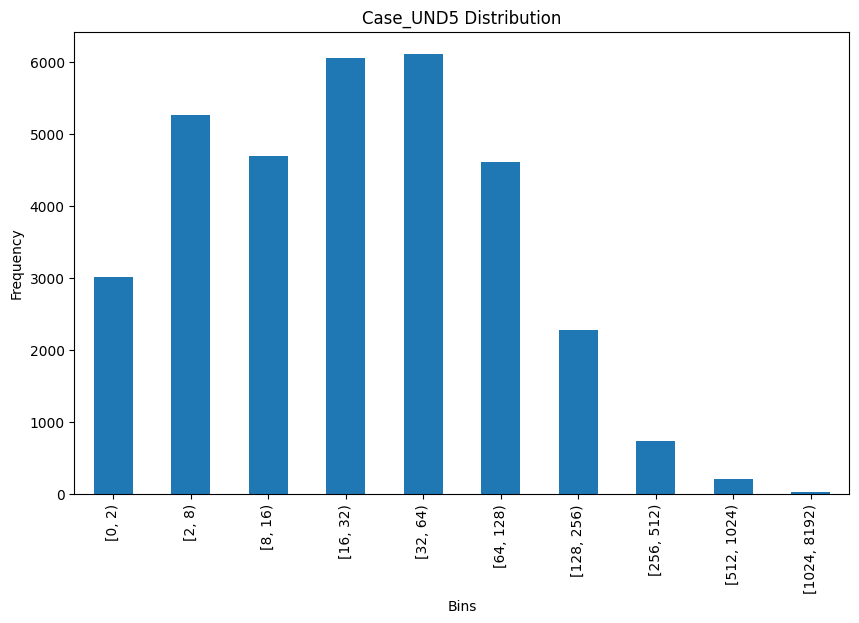

In [26]:
target_col = 'Case_UND5'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Case_OVR5 Distribution'}, xlabel='Bins', ylabel='Frequency'>

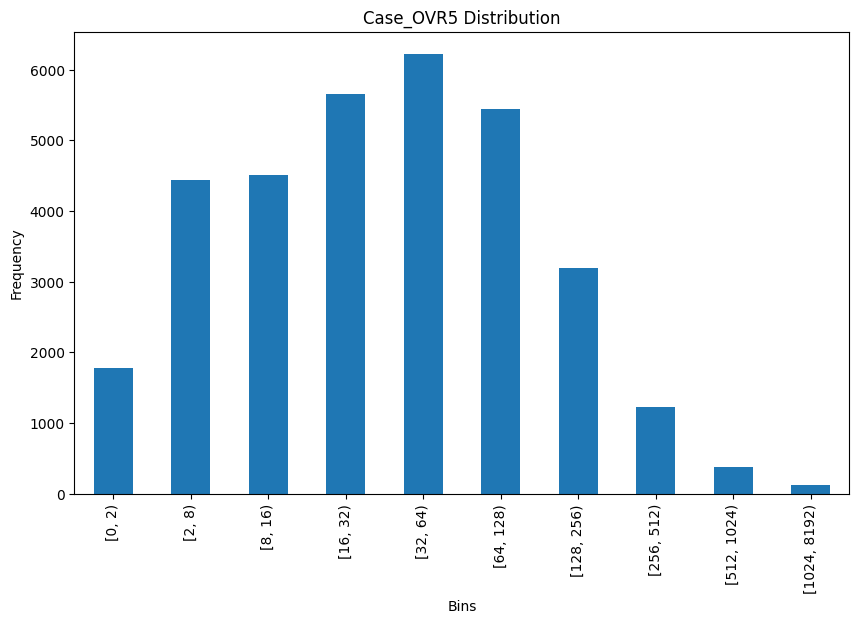

In [27]:
target_col = 'Case_OVR5'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Case_PRGN Distribution'}, xlabel='Bins', ylabel='Frequency'>

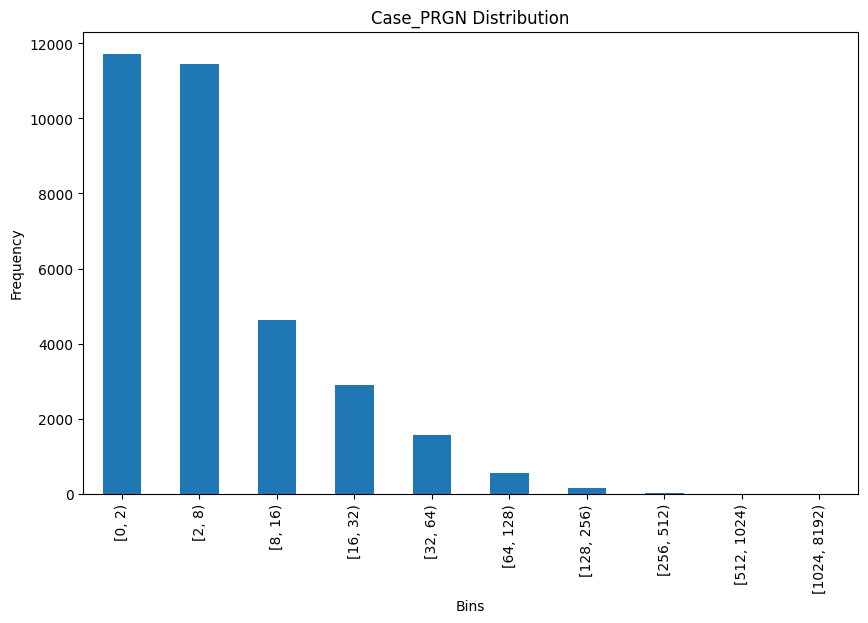

In [28]:
target_col = 'Case_PRGN'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Case_TOTAL Distribution'}, xlabel='Bins', ylabel='Frequency'>

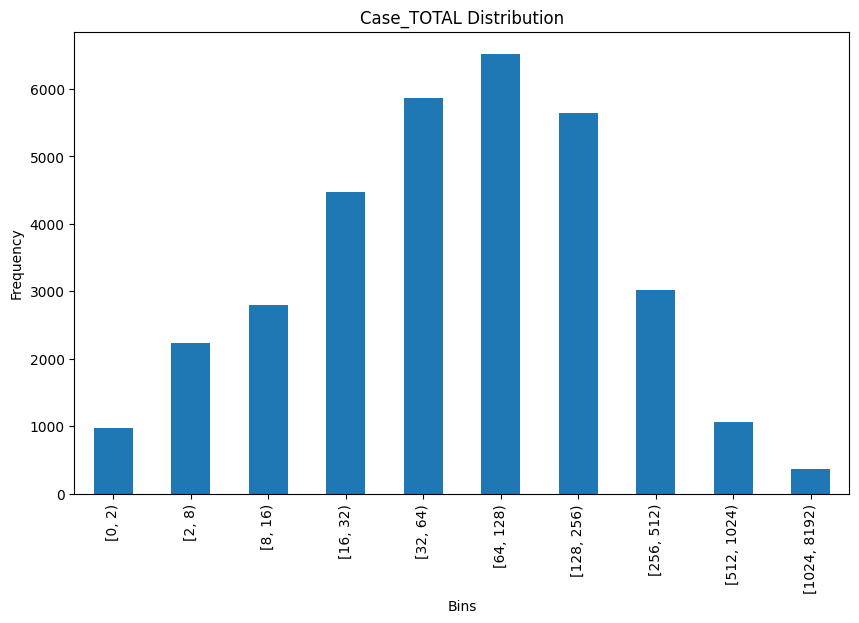

In [29]:
target_col = 'Case_TOTAL'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Sevr_UND5 Distribution'}, xlabel='Bins', ylabel='Frequency'>

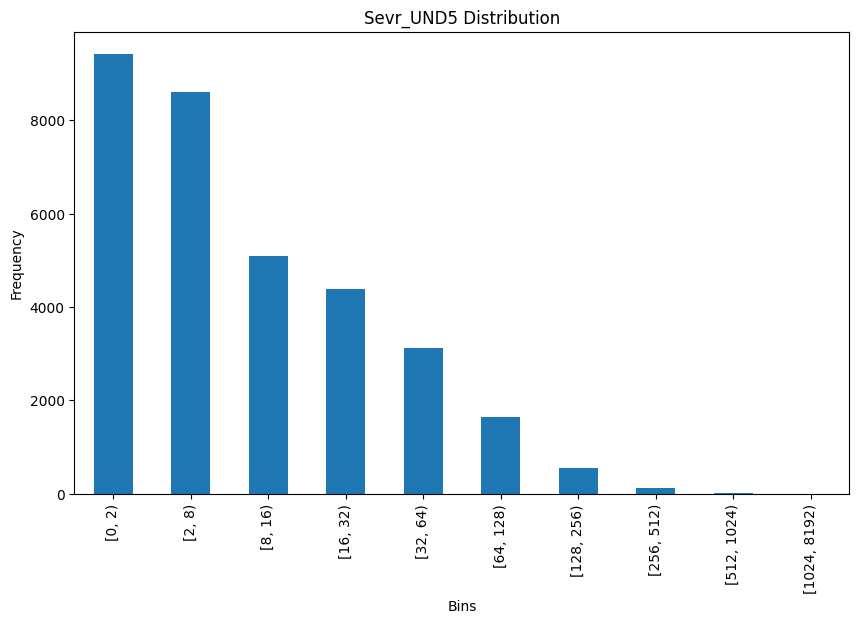

In [30]:
target_col = 'Sevr_UND5'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Sevr_OVR5 Distribution'}, xlabel='Bins', ylabel='Frequency'>

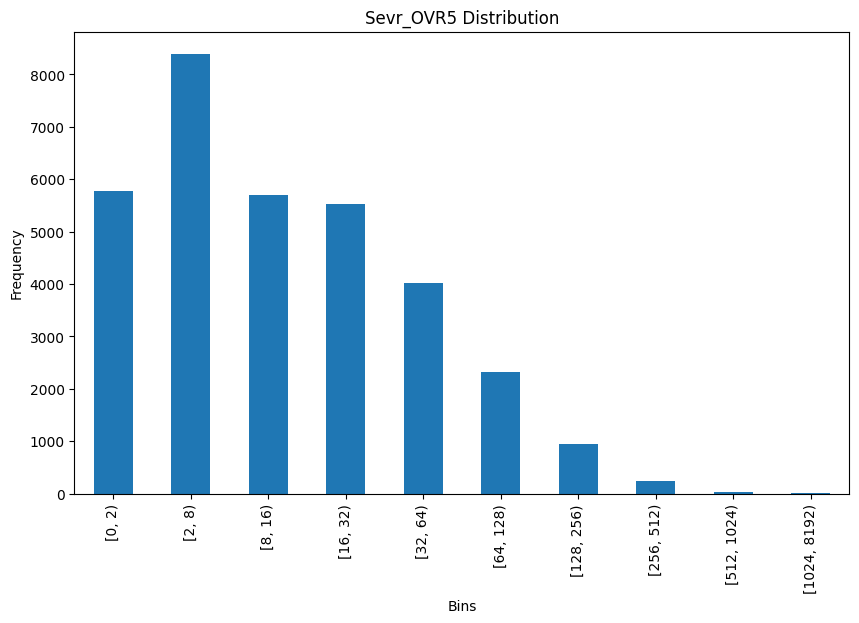

In [31]:
target_col = 'Sevr_OVR5'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Sevr_PRGN Distribution'}, xlabel='Bins', ylabel='Frequency'>

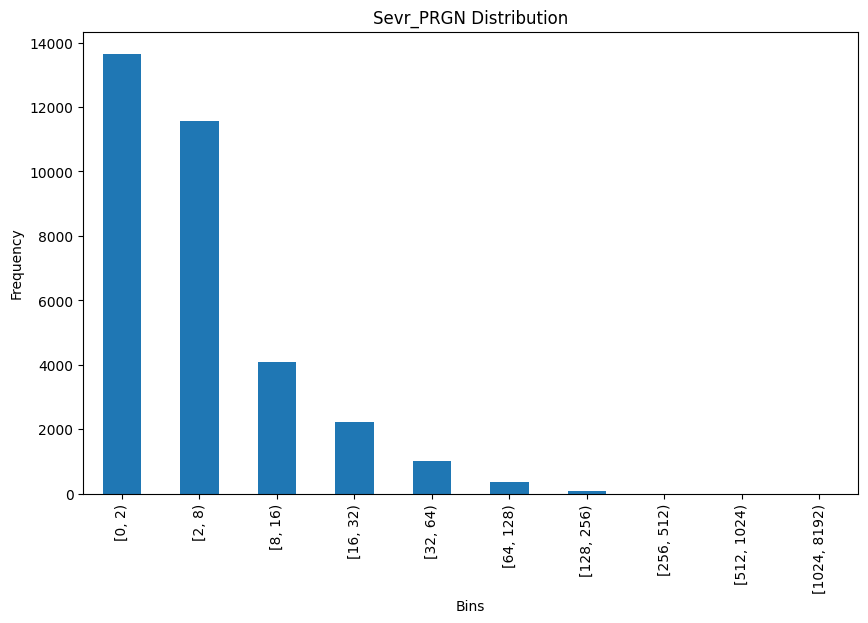

In [32]:
target_col = 'Sevr_PRGN'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Sevr_TOTAL Distribution'}, xlabel='Bins', ylabel='Frequency'>

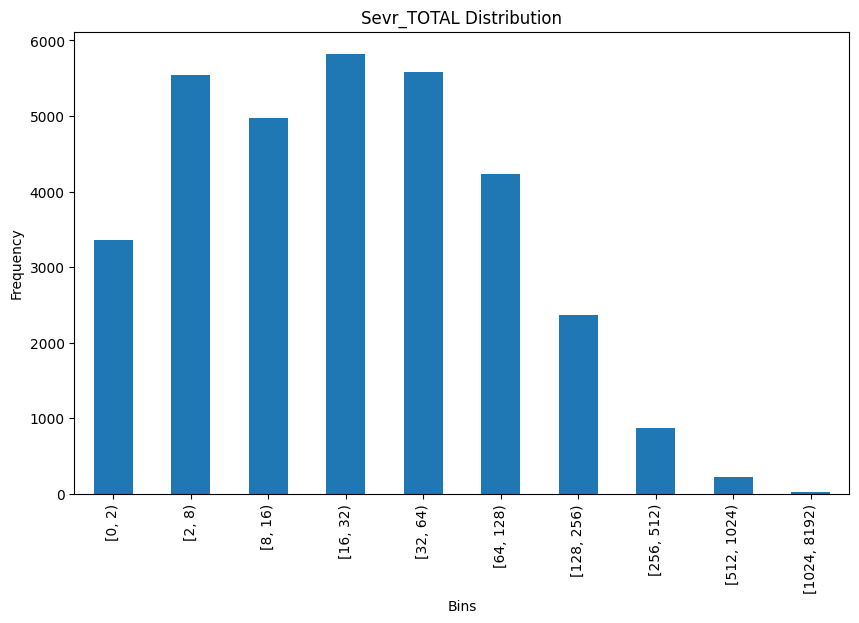

In [33]:
target_col = 'Sevr_TOTAL'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Hosp_UND5 Distribution'}, xlabel='Bins', ylabel='Frequency'>

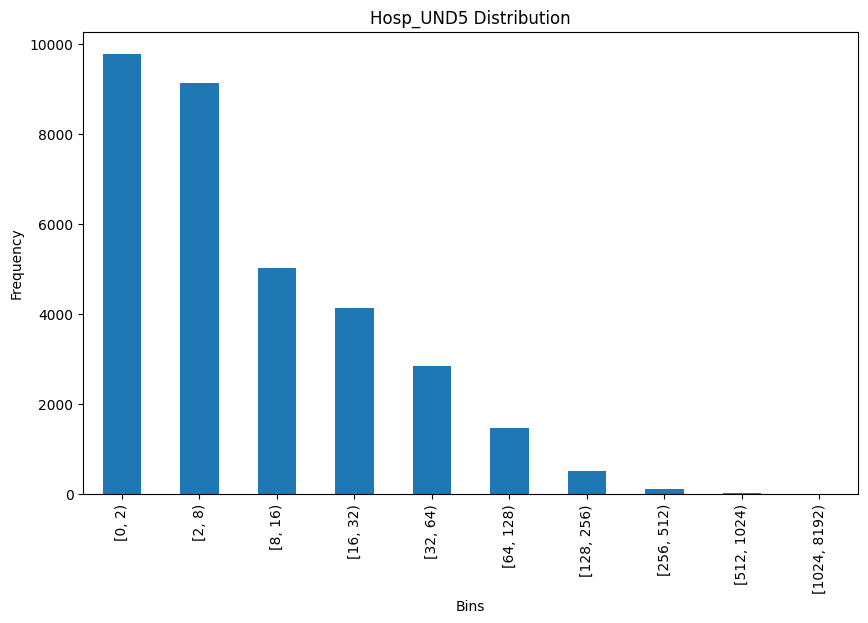

In [34]:
target_col = 'Hosp_UND5'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Hosp_OVR5 Distribution'}, xlabel='Bins', ylabel='Frequency'>

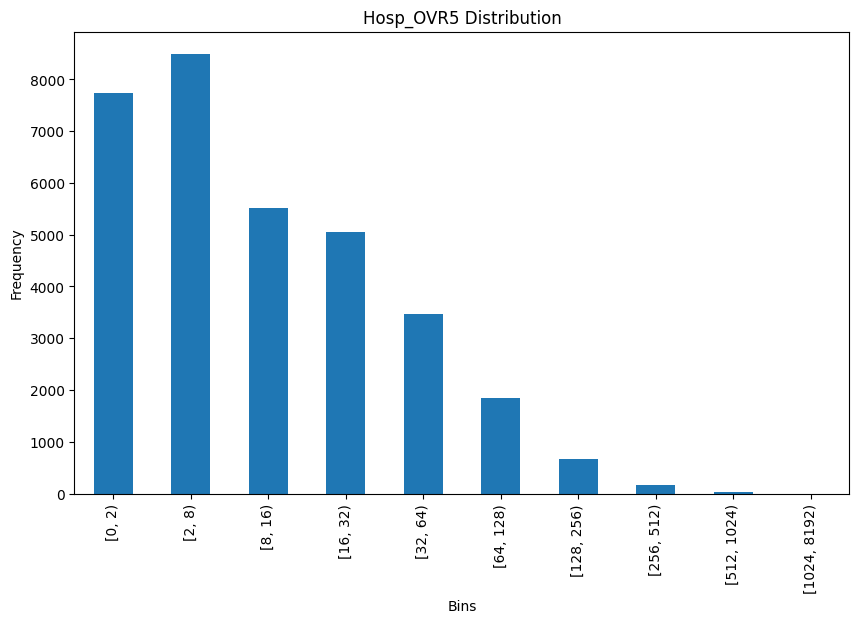

In [35]:
target_col = 'Hosp_OVR5'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Hosp_PRGN Distribution'}, xlabel='Bins', ylabel='Frequency'>

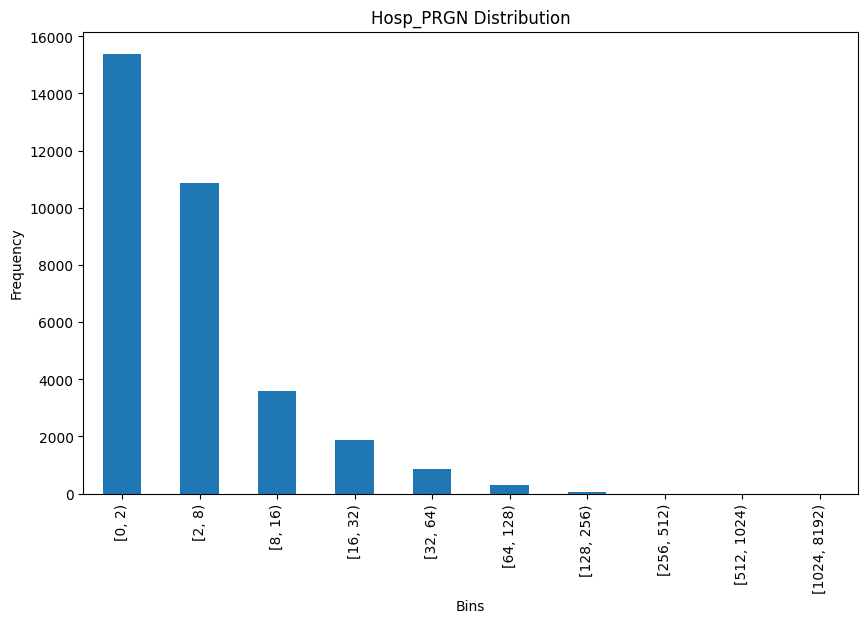

In [36]:
target_col = 'Hosp_PRGN'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Hosp_TOTAL Distribution'}, xlabel='Bins', ylabel='Frequency'>

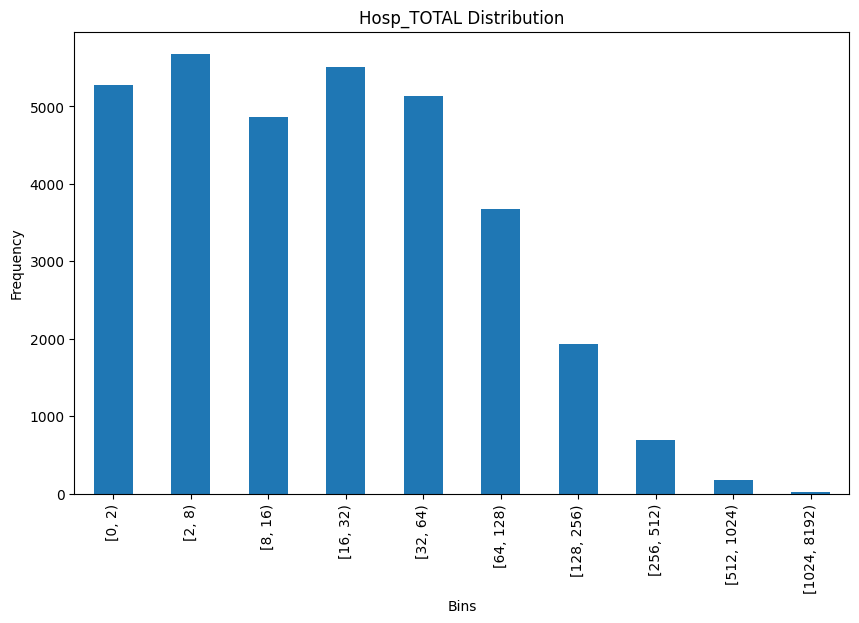

In [37]:
target_col = 'Hosp_TOTAL'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Death_UND5 Distribution'}, xlabel='Bins', ylabel='Frequency'>

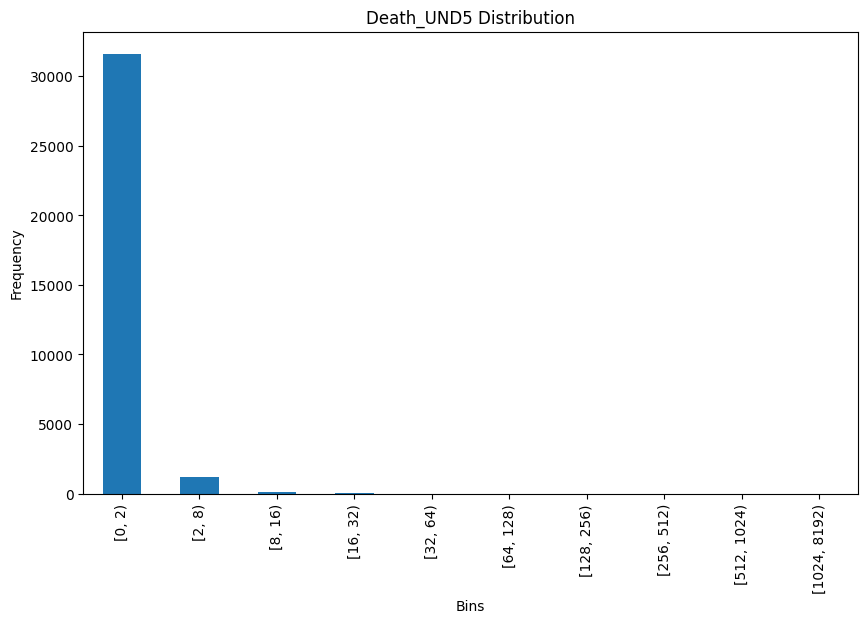

In [38]:
target_col = 'Death_UND5'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Death_OVR5 Distribution'}, xlabel='Bins', ylabel='Frequency'>

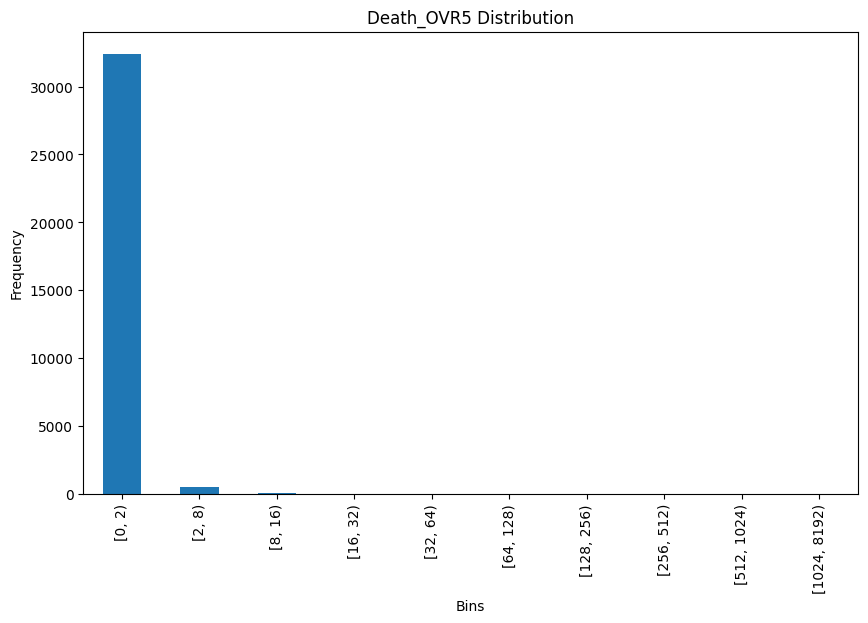

In [39]:
target_col = 'Death_OVR5'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Death_PRGN Distribution'}, xlabel='Bins', ylabel='Frequency'>

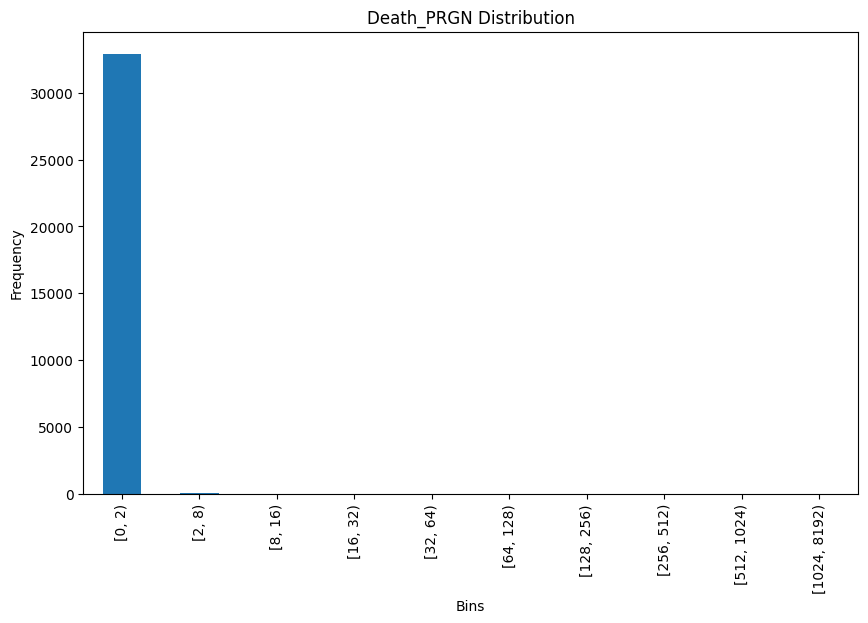

In [40]:
target_col = 'Death_PRGN'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

<Axes: title={'center': 'Death_TOTAL Distribution'}, xlabel='Bins', ylabel='Frequency'>

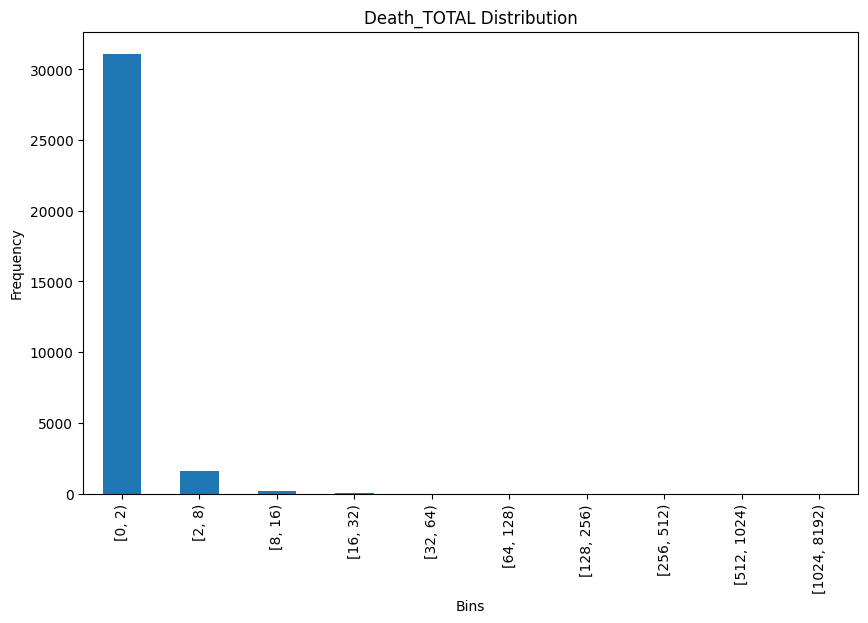

In [41]:
target_col = 'Death_TOTAL'

pd.cut(dataset[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')